In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime, timedelta
import random
from scipy.signal import savgol_filter
from collections import defaultdict

from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook
output_notebook()

from bokeh.palettes import (
    Colorblind)


Loading BokehJS ...

In [4]:
data_files = ["game_metadata","nintendo","steam","survey_biweekly","survey_daily","survey_intake","timeuse","xbox"]

game_metadata = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/game_metadata.csv", parse_dates=["release_date"])
nintendo = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/nintendo.csv", parse_dates=["session_end", "session_start"])
steam = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/steam.csv", parse_dates=["approximate_session_start", "approximate_session_end"])
survey_biweekly = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_biweekly.csv", parse_dates=["date"])
survey_daily = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_daily.csv", parse_dates=["date"])
survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")
timeuse = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/timeuse.csv", parse_dates=["start_time", "end_time"])
xbox = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/xbox.csv", parse_dates=["session_end", "session_start"])
ios = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/ios.csv")
android = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/android.csv")

steam.rename(columns=
    {
    "approximate_session_start" : "session_start",
    "approximate_session_end" : "session_end",
    "minutes" : "duration"
    }, inplace=True)

user_info = survey_intake.set_index("pid").to_dict("index")
xbox["platform"] = xbox.apply(lambda _: 'xbox', axis=1)
steam["platform"] = steam.apply(lambda _: 'steam', axis=1)
nintendo["platform"] = nintendo.apply(lambda _: 'nintendo', axis=1)

gaming_logs = pd.concat([xbox[["pid", "title_id", "session_start", "session_end", ".had_overlap", "duration", "platform"]], 
           steam[["pid", "title_id", "session_start", "session_end", "duration", "playtime_forever", "platform"]],
           nintendo[["pid",	"title_id",	"session_start",	"session_end",	"duration", "platform"]]
           ], ignore_index=True)

/tmp/ipykernel_66403/1731244082.py:8: DtypeWarning: Columns (10: local_timezone, 38: android_uses_family, 39: ios_uses_family, 41: xbox_uses_family, 51: neuro_diag_tourette, 54: neuro_diag_nvld, 56: neuro_diag_prefer_not_say, 60: neuro_iden_dyslexia, 62: neuro_iden_dyscalculia, 63: neuro_iden_tourette, 65: neuro_iden_spd, 66: neuro_iden_nvld, 68: neuro_iden_prefer_not_say, 74: care_prefer_not_say, 75: care_other, 78: wemwbs_1, 79: wemwbs_2, 80: wemwbs_3, 81: wemwbs_4, 82: wemwbs_5, 83: wemwbs_6, 84: wemwbs_7) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_intake = pd.read_csv("digital-wellbeing-open-play-eb0a68c/data/clean/survey_intake.csv")


In [7]:
survey_biweekly["wellbeing_index"] = (((survey_biweekly.life_sat * 4)/10) + 
    40 - (survey_biweekly.promis_1 + survey_biweekly.promis_2 + survey_biweekly.promis_3 + survey_biweekly.promis_4 + 
    survey_biweekly.promis_5 + survey_biweekly.promis_6 + survey_biweekly.promis_7 + survey_biweekly.promis_8) + 
    survey_biweekly.wemwbs_1 + survey_biweekly.wemwbs_2 + survey_biweekly.wemwbs_3 + survey_biweekly.wemwbs_4 +  
    survey_biweekly.wemwbs_5 + survey_biweekly.wemwbs_6 + survey_biweekly.wemwbs_7 - 7)/16 * 10/4

def playtime_2weeks(row, gaming_logs):
    return gaming_logs[(gaming_logs.pid == row.pid) & (row.date - timedelta(days=14) < gaming_logs.session_start) & (gaming_logs.session_start < row.date)].duration.sum()/14

survey_biweekly["playtime_2weeks"] = survey_biweekly.apply(playtime_2weeks, args=(gaming_logs,), axis=1)

total_playtime_ever_per_pid = gaming_logs.groupby(by="pid").duration.sum().to_dict()
survey_biweekly["total_playtime_ever"] = survey_biweekly.pid.apply(lambda pid: total_playtime_ever_per_pid.get(pid, 0))


In [20]:
users_with_data = survey_biweekly[survey_biweekly.total_playtime_ever > 0]
users_with_data = users_with_data.to_csv("users_with_data.csv", index=False)

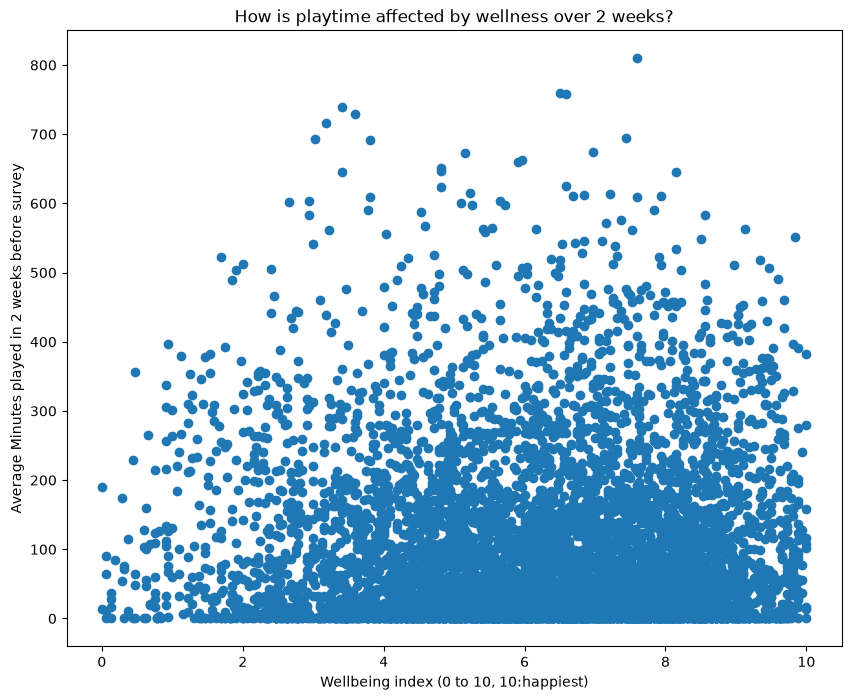

In [23]:
# Wellness v/s playtime graph

users_with_data = pd.read_csv("users_with_data.csv", parse_dates=["date"])

plt.figure(figsize=(10, 8))
plt.scatter(users_with_data.wellbeing_index, users_with_data.playtime_2weeks)
plt.xlabel("Wellbeing index (0 to 10, 10:happiest)")
plt.ylabel("Average Minutes played in 2 weeks before survey")
plt.title("How is playtime affected by wellness over 2 weeks?")
plt.show()

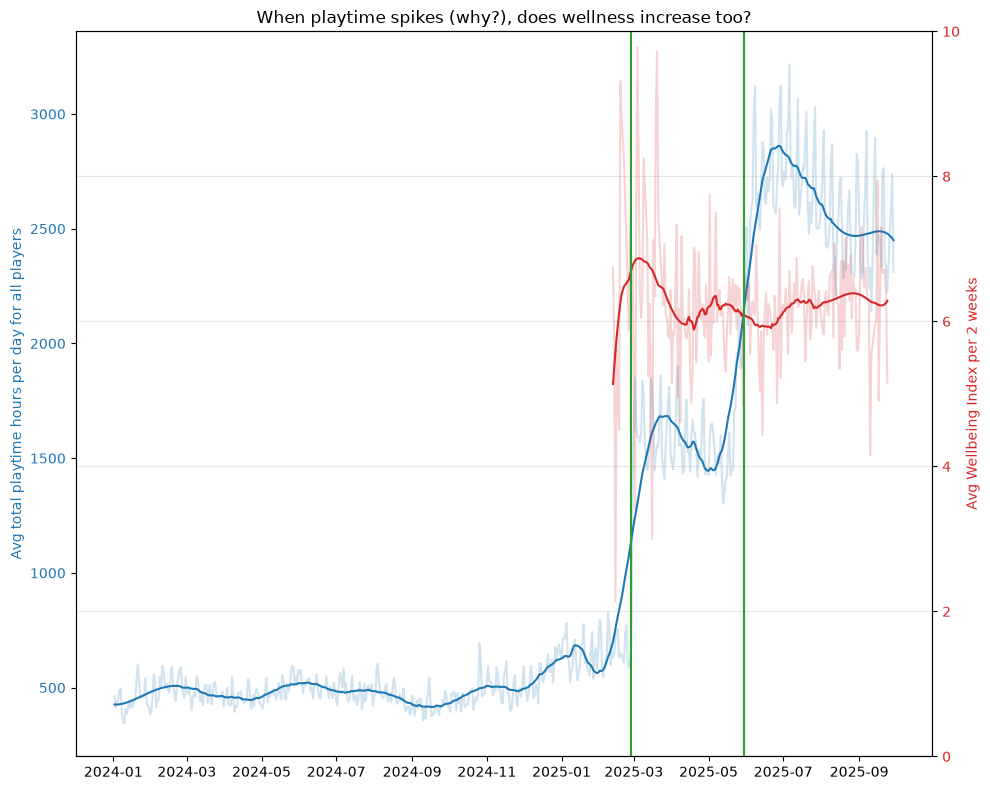

In [28]:
# grouped playtime for all players who answered in survey

per_day_2025 = gaming_logs[(gaming_logs.session_start.dt.date > date(2024, 1, 1)) & (gaming_logs.session_start.dt.date < date(2025, 9, 30))]

log_and_survey = {}
for pid in per_day_2025.pid.unique():
    log_and_survey[pid] = True if pid in users_with_data.pid.to_list() else False

per_day_2025["survey"] = per_day_2025.pid.apply(lambda pid: log_and_survey[pid])
per_day_2025 = per_day_2025[per_day_2025.survey == True]
per_day_2025 = per_day_2025.groupby(per_day_2025.session_start.dt.date, as_index=False).duration.sum()
per_day_2025.rename(columns={"duration" : "avg_duration",
                             "session_start" : "date"}, inplace=True)
per_day_2025.avg_duration = per_day_2025.avg_duration/60

biweekly_wellbeing = users_with_data[["pid", "date", "wellbeing_index"]].reset_index(drop=True)
biweekly_wellbeing.date = biweekly_wellbeing.date.dt.date
biweekly_wellbeing = biweekly_wellbeing.groupby("date", as_index=False).wellbeing_index.mean()
biweekly_wellbeing = biweekly_wellbeing[biweekly_wellbeing.wellbeing_index.notna() == True]

per_day_2025["avg_duration_smooth"] = savgol_filter(per_day_2025.avg_duration, 100, 4)
biweekly_wellbeing["wellbeing_index_smooth"] = savgol_filter(biweekly_wellbeing.wellbeing_index, 100, 6)

fig, ax1 = plt.subplots(figsize=(10,8))

color = "tab:blue"
ax1.set_ylabel("Avg total playtime hours per day for all players", color=color)
ax1.plot(per_day_2025.date, per_day_2025.avg_duration_smooth, c=color)
ax1.tick_params(axis="y", labelcolor=color)

ax1.plot(per_day_2025.date, per_day_2025.avg_duration, c=color, alpha=0.2)

ax2 = ax1.twinx() 
color = "tab:red"
ax2.set_ylabel("Avg Wellbeing Index per 2 weeks", color=color)  
ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index_smooth, color=color)
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(0, 10)

ax2.plot(biweekly_wellbeing.date, biweekly_wellbeing.wellbeing_index, color=color, alpha=0.2)

plt.axvline(date(2025, 5, 30), c="tab:green")
plt.axvline(date(2025, 2, 27), c="tab:green")
plt.title("When playtime spikes (why?), does wellness increase too?")

fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()


In [31]:
game_keywords = game_metadata[["original_name", "keywords"]].set_index("original_name").to_dict(orient="dict")
per_pid = pd.DataFrame(gaming_logs.groupby(["pid", "title_id"], as_index=False).duration.sum())
per_pid = per_pid[per_pid.duration > 1000]
per_pid["gender"] = per_pid.pid.apply(lambda pid: user_info[pid]["gender"])
per_pid["keywords"] = per_pid.title_id.apply(lambda title: game_keywords["keywords"].get(title, 0))
per_pid = per_pid[per_pid.keywords.notna() == True]
per_pid = per_pid[per_pid.gender.isin(["Man", "Woman", "Non-binary"]) == True].reset_index(drop=True)

gender_keyword = defaultdict(dict)
keyword_exp = ["male protagonist", "female protagonist", "magic", "cooking", "pvp", "cozy"]

for keyword in keyword_exp:
    gender_keyword[keyword].update(per_pid.apply(lambda row: row["gender"] if keyword in row["keywords"] else 0, axis=1).value_counts().to_dict())

gender_keyword_wo_0 = pd.DataFrame(gender_keyword).reset_index().rename(columns={"index" : "gender"})
gender_keyword_wo_0 = gender_keyword_wo_0[gender_keyword_wo_0.gender != 0]

In [35]:
labels = gender_keyword_wo_0.columns[1:]
source = ColumnDataSource(gender_keyword_wo_0)

p = figure(width=600, height=400, title="Gender v/s Game Keywords")
p.hbar_stack(gender_keyword_wo_0.columns[1:].values, 
            y="gender", 
            height=0.6, 
            source=source,
            color=Colorblind[len(gender_keyword_wo_0.columns[1:])])                        
p.ygrid.grid_line_color = None
show(p)